# ICA04 — Working with geogrid output (wrfout) in Python

This notebook is a streamlined introduction to reading and plotting geogrid `geo_em` files with xarray.

Julie.Lundquist@JHU.edu
2026 February (updated from 2023 version)

## Learning goals
By the end, you should be able to:
1. Open a `geo_em*` NetCDF file with `xarray` and make domain plots of map factor, terrain height, and land/sea masks
2. Assess variability of map factors to understand benefits/limitations of different projections

> **Tip:** Note that latitude, longitude, and map factors are all available on cell center grids (_M), u grids (_U), and v grids (_V).


In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path
import glob

from matplotlib.axes import Axes # Makes the color bar easier to work with
from mpl_toolkits.axes_grid1 import make_axes_locatable # Color bar location
import matplotlib.ticker as mticker


from matplotlib.colors import ListedColormap, BoundaryNorm # Because I'm particular about color tables
from matplotlib.colors import Normalize # Because I'm particular about color tables
from matplotlib.colors import TwoSlopeNorm # to help normalize map factors so color table is centered on zero


print("Imports OK")

Imports OK


In [2]:
# Julie is particular about color tables for terrain....

class WaterLandNormalize(Normalize):
    def __init__(self, vmin=0, vmax=1000, water_frac=0.2, clip=False):
        self.water_frac = water_frac
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        value = np.asarray(value)

        # Initialize normalized array
        result = np.zeros_like(value, dtype=float)

        # Water (HGT == 0)
        water = value <= 0
        result[water] = 0.0

        # Land (HGT > 0)
        land = value > 0
        result[land] = self.water_frac + (
            (value[land] - 0) / (self.vmax - 0)
        ) * (1.0 - self.water_frac)

        return np.ma.masked_array(result)


## 1) Point to your data

Set `DATA_DIR` to the folder containing your WRF output files (e.g., `wrfout_d01_YYYY-MM-DD_HH:MM:SS`).

If you're working on a shared system, copy the files you need into a directory you can read quickly (scratch or project space).


In [3]:
# --- Edit this path ---
DATA_DIR = Path(".")  # STUDENTS EDIT THIS Path("/path/to/your/wrfout/files")
DATA_DIR = Path("/home/jlundqui/EN530.462/AtmosphericModelingLab/ICA04/")
# Find geo_em files
geo_em_file = 'geo_em.d01.nc' 


# Find candidate wrfout files
geo_em_files = sorted(DATA_DIR.glob("geo_em.d0*"))  # matches geo_em.d0*...
print(f"Found {len(geo_em_files)} geo_em file(s) in {DATA_DIR.resolve()}")

# If you have many files, you can pick one:
if len(geo_em_files) == 0:
    raise FileNotFoundError(
        "No geo_em_files found. Update DATA_DIR to the folder that contains geo_em_files."
    )

GEO_EM_FILE = geo_em_files[0]
print("Using:", GEO_EM_FILE.name)


Found 1 geo_em file(s) in /home/jlundqui/EN530.462/AtmosphericModelingLab/ICA04
Using: geo_em.d01.nc


## 2) Open the dataset with xarray

For teaching purposes we open without dask chunking. If your file is large, ask and we can switch to chunked reads.


In [4]:
ds = xr.open_dataset(GEO_EM_FILE)

# Quick look (in Jupyter this renders nicely)
ds

<xarray.Dataset>
Dimensions:     (Time: 1, south_north: 201, west_east: 201,
                 south_north_stag: 202, west_east_stag: 202, land_cat: 21,
                 soil_cat: 16, month: 12, num_urb_params: 132,
                 dust_erosion_dimension: 3)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month,
                                num_urb_params, dust_erosion_dimension
Data variables: (12/82)
    Times       (Time) |S19 ...
    XLAT_M      (Time, south_north, west_east) float32 ...
    XLONG_M     (Time, south_north, west_east) float32 ...
    XLAT_V      (Time, south_north_stag, west_east) float32 ...
    XLONG_V     (Time, south_north_stag, west_east) float32 ...
    XLAT_U      (Time, south_north, west_east_stag) float32 ...
    ...          ...
    OA4SS       (Time, south_north, west_east) float32 ...
    OL1SS       (Time, south_north, west_east) float32 ...
    OL2SS       (Time, south_north, west_east) float32 ...
    OL3SS       (Time, south_north, west_east) float32 ...
    OL4SS       (Time, south_north, west_east) float32 ...
    BATHYMETRY  (Time, south_north, west_east) float32 ...
Attributes: (12/56)
    TITLE:                           OUTPUT FROM GEOGRID V4.6.0
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        202
    SOUTH-NORTH_GRID_DIMENSION:      202
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    FLAG_IMPERV:                     1
    FLAG_CANFRA:                     1
    FLAG_EROD:                       1
    FLAG_CLAYFRAC:                   1
    FLAG_SANDFRAC:                   1
    FLAG_BATHYMETRY:                 1

## 3) Inspect dimensions and variables

In [5]:
print("Dimensions:")
for k, v in ds.dims.items():
    print(f"  {k}: {v}")

# Show a short list of variables (first ~30)
vars_list = list(ds.data_vars)
print("\nData variables (first 30):")
print(vars_list[:30])

Dimensions:
  Time: 1
  south_north: 201
  west_east: 201
  south_north_stag: 202
  west_east_stag: 202
  land_cat: 21
  soil_cat: 16
  month: 12
  num_urb_params: 132
  dust_erosion_dimension: 3

Data variables (first 30):
['Times', 'XLAT_M', 'XLONG_M', 'XLAT_V', 'XLONG_V', 'XLAT_U', 'XLONG_U', 'CLAT', 'CLONG', 'MAPFAC_M', 'MAPFAC_V', 'MAPFAC_U', 'MAPFAC_MX', 'MAPFAC_VX', 'MAPFAC_UX', 'MAPFAC_MY', 'MAPFAC_VY', 'MAPFAC_UY', 'E', 'F', 'SINALPHA', 'COSALPHA', 'LANDMASK', 'XLAT_C', 'XLONG_C', 'SINALPHA_U', 'COSALPHA_U', 'SINALPHA_V', 'COSALPHA_V', 'LANDUSEF']


## 4) Get lat/lon and plot the domain

In geogrid files, if you want cell centers, you need 'XLAT_M' and 'XLLONG_M', instead of `XLAT` and `XLONG`.  

Cartopy gridline labels and colorbars both live outside the map axes.
The safest approach is to give the colorbar its own axis.


Map bounds [lon_min, lon_max, lat_min, lat_max]: [-81.60797119140625, -74.39202880859375, 36.25310516357422, 41.697383880615234]
[OK] Saved figure → HGT.png


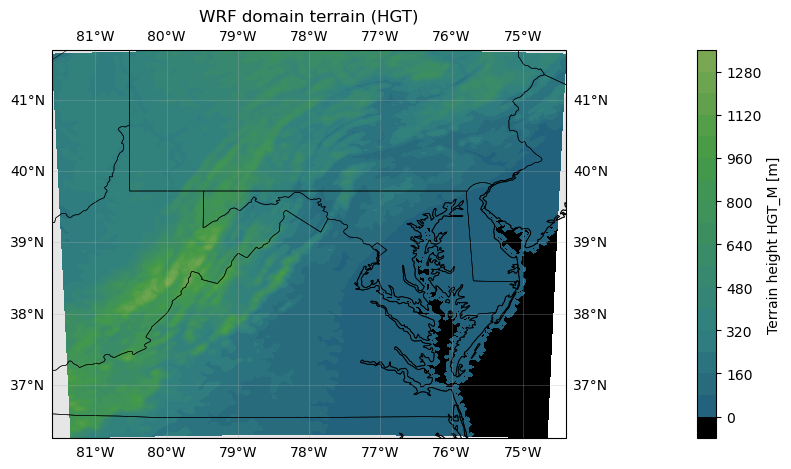

In [6]:
# 2D lat/lon for mapping
lat = ds["XLAT_M"].isel(Time=0)
lon = ds["XLONG_M"].isel(Time=0)

# Terrain height HGT (meters)
hgt = ds["HGT_M"].isel(Time=0)

bounds = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]
print("Map bounds [lon_min, lon_max, lat_min, lat_max]:", bounds)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)


ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

norm = WaterLandNormalize(vmin=0, vmax=3000, water_frac=0.2)

cf = ax.contourf(
    lon, lat, hgt,
    levels=20,
    cmap="gist_earth",
    norm=norm,
    transform=proj,
)


divider = make_axes_locatable(ax)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("Terrain height HGT_M [m]")
# cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])


ax.set_title("WRF domain terrain (HGT)")
fig.tight_layout()

save='HGT.png'
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")


plt.show()



## 5) Plot the map factor to assess distortion for one geogrid file


[OK] Saved figure → MAPFAC.png


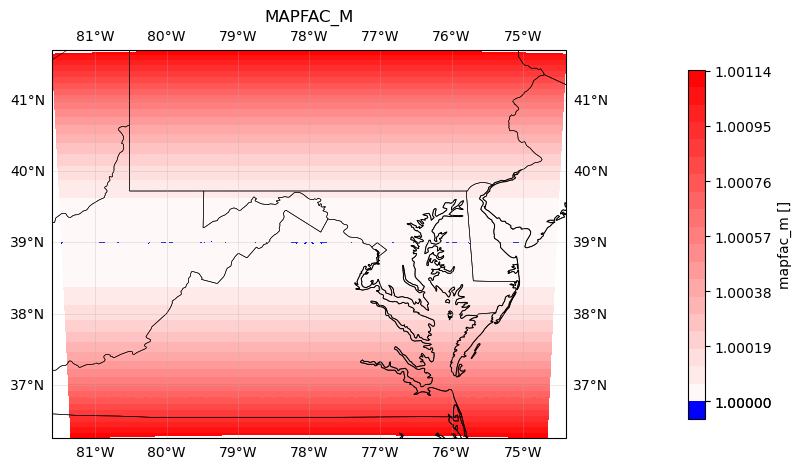

In [7]:

mapfac_m = ds["MAPFAC_M"].isel(Time=0) 

vmin = float(mapfac_m.min())
vmax = float(mapfac_m.max())

norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)
ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)


divider = make_axes_locatable(ax)

cf = ax.contourf(lon, lat, mapfac_m, levels=21, transform=proj, cmap='bwr', norm=norm)

cbar = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)

# Force ticks, including exactly 1.0
ticks = np.linspace(vmin, vmax, 7)
ticks = np.sort(np.append(ticks, 1.0))

cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.5f}" for t in ticks])

cbar.set_label("MAPFAC_M []")

cbar.set_label("mapfac_m []")

ax.set_title("MAPFAC_M")

plt.tight_layout()

save='MAPFAC.png'
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()

In [8]:
landmask = ds["LANDMASK"].isel(Time=0) 
landmask

<xarray.DataArray 'LANDMASK' (south_north: 201, west_east: 201)>
array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.]], dtype=float32)
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    units:        none
    description:  Landmask : 1=land, 0=water
    stagger:      M
    sr_x:         1
    sr_y:         1

[OK] Saved figure → LANDMASK.png


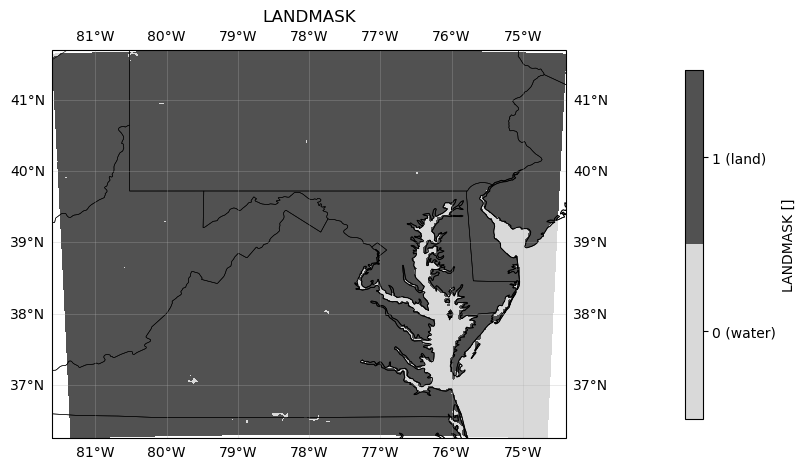

In [9]:
## Assess the land sea mask


# --- pick the mask variable name used in your file ---
landmask = ds["LANDMASK"].isel(Time=0)   # 0=water, 1=land (typical WRF)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)
ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

divider = make_axes_locatable(ax)


# Levels that separate 0 and 1 cleanly:
levels = [-0.5, 0.5, 1.5]

cf = ax.contourf(
    lon, lat, landmask,
    levels=levels,
    transform=proj,
    cmap="Greys",   # or "Blues", "binary", etc.
    extend="neither"
)

# # Optional: draw the land/sea boundary (where mask changes)
# cs = ax.contour(
#     lon, lat, landmask,
#     levels=[0.5],
#     colors="k",
#     linewidths=0.8,
#     transform=proj
# )

cbar = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0 (water)", "1 (land)"])
cbar.set_label("LANDMASK []")

ax.set_title("LANDMASK")

plt.tight_layout()
save = "LANDMASK.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")
plt.show()


[OK] Saved figure → LANDMASK.png


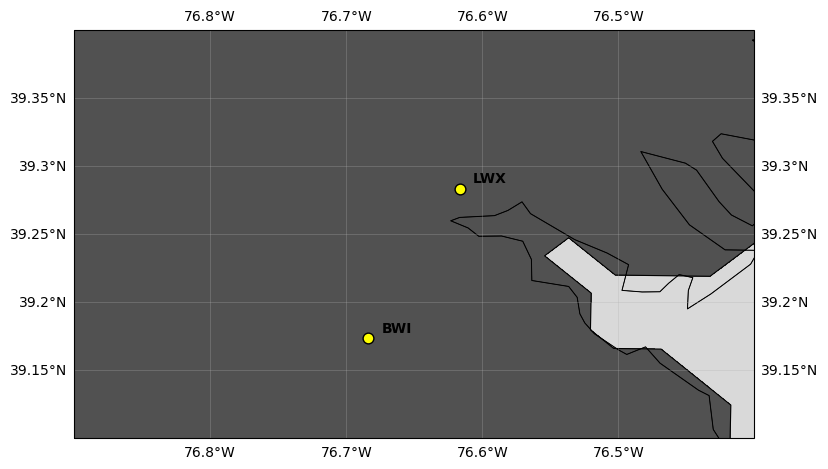

In [10]:
# zoom in on Baltimore City - is the inner harbor represented at all?
## Assess the land sea mask

landmask = ds["LANDMASK"].isel(Time=0)   # 0=water, 1=land (typical WRF)

bounds = [-76.9, -76.4, 39.1, 39.4] # subset to zoom in on Inner Harbor

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)
ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

divider = make_axes_locatable(ax)


# Levels that separate 0 and 1 cleanly:
levels = [-0.5, 0.5, 1.5]

cf = ax.contourf(
    lon, lat, landmask,
    levels=levels,
    transform=proj,
    cmap="Greys",   # or "Blues", "binary", etc.
    extend="neither"
)

# Optional: draw the land/sea boundary (where mask changes)
cs = ax.contour(
    lon, lat, landmask,
    levels=[0.5],
    colors="k",
    linewidths=0.8,
    transform=proj
)

# LWX location
lwx_lat = 39.28333
lwx_lon = -76.61667

# Plot the point
ax.scatter(
    lwx_lon, lwx_lat,
    color="yellow",
    edgecolor="k",
    s=60,
    zorder=5,
    transform=proj
)

# Add the label
ax.text(
    lwx_lon + 0.01, lwx_lat + 0.005,  # small offset so text doesn't overlap dot
    "LWX",
    fontsize=10,
    fontweight="bold",
    color="black",
    transform=proj,
    zorder=6
)
###### 
# BWI location
bwi_lat = 39.17329
bwi_lon = -76.68408

# Plot the point
ax.scatter(
    bwi_lon, bwi_lat,
    color="yellow",
    edgecolor="k",
    s=60,
    zorder=5,
    transform=proj
)

# Add the label
ax.text(
    bwi_lon + 0.01, bwi_lat + 0.005,  # small offset so text doesn't overlap dot
    "BWI",
    fontsize=10,
    fontweight="bold",
    color="black",
    transform=proj,
    zorder=6
)


# cbar = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(["0 (water)", "1 (land)"])
# cbar.set_label("LANDMASK []")

# ax.set_title("LANDMASK")

plt.tight_layout()
save = "LANDMASK.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")
plt.show()


## 6) Read in and compare all four sets of projections

Here we compare map factor from four different projection runs with an assumed directory structure.


In [11]:
# Open all your geogrid files using a library type approach


DATA_DIR = Path("/home/jlundqui/EN530.462/AtmosphericModelingLab/ICA04")

subdirs = {
    "lambert3939": DATA_DIR / "lambert3939",
    "lambert3060": DATA_DIR / "lambert3060",
    "mercator": DATA_DIR / "mercator",
    "polar": DATA_DIR / "polar",
}

datasets = {}

for name, d in subdirs.items():
    files = sorted(d.glob("geo_em.d0*.nc"))
    if len(files) == 0:
        raise FileNotFoundError(f"No geo_em file found in {d}")
    if len(files) > 1:
        print(f"[WARN] Multiple geo_em files in {d}, using {files[0].name}")

    datasets[name] = xr.open_dataset(files[0])
    print(f"[OK] Loaded {name}: {files[0].name}")



[OK] Loaded lambert3939: geo_em.d01.nc
[OK] Loaded lambert3060: geo_em.d01.nc
[OK] Loaded mercator: geo_em.d01.nc
[OK] Loaded polar: geo_em.d01.nc


[OK] Saved figure → MAPFAC_M_compare_4projections.png


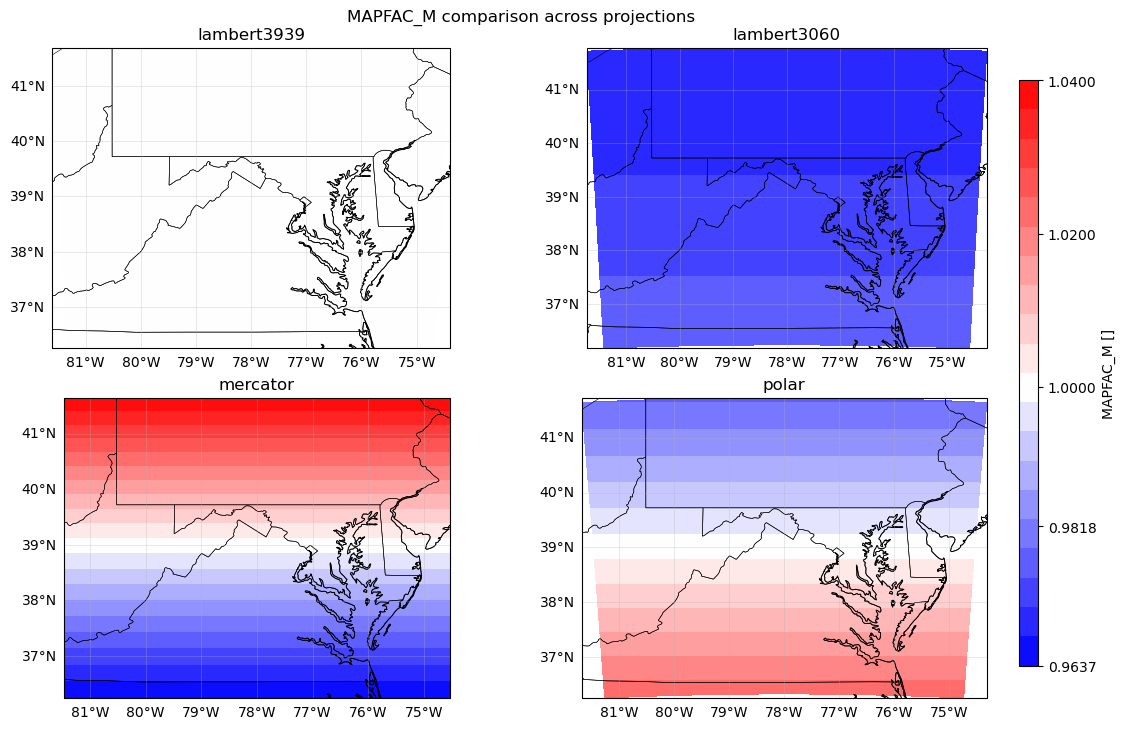

In [12]:
# Make a four-panel plot:
# Choose plotting order
order = ["lambert3939", "lambert3060", "mercator", "polar"]

# --- compute global vmin/vmax across all four so colors are comparable ---
mapfac_all = []
for name in order:
    mf = datasets[name]["MAPFAC_M"].isel(Time=0)
    mapfac_all.append(mf)

vmin = float(min(mf.min().item() for mf in mapfac_all))
vmax = float(max(mf.max().item() for mf in mapfac_all))

norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

levels = np.linspace(vmin, vmax, 21)  # explicit boundaries shared by all panels


proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 7),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

axes = axes.ravel()
mappable = None

for ax, name in zip(axes, order):
    ds = datasets[name]
    mapfac_m = ds["MAPFAC_M"].isel(Time=0)

    # Grab lat/lon from each dataset (adjust names if yours differ)
    lat = ds["XLAT_M"].isel(Time=0)
    lon = ds["XLONG_M"].isel(Time=0)

    bounds = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]

    ax.set_extent(bounds, crs=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    cf = ax.contourf(
        lon, lat, mapfac_m,
        levels=levels,
        transform=proj,
        cmap="bwr",
        norm=norm,
        extend="neither"
    )
    
    
    ax.set_title(name)
    mappable = cf  # keep last one for colorbar

    
from matplotlib.ticker import FormatStrFormatter

# --- shared colorbar ---
cbar = fig.colorbar(
    mappable,
    ax=axes,
    pad=0.03,
    shrink=0.9,
    aspect=30   # makes it wider / more readable
)

# Choose clean, meaningful ticks
ticks = np.array([
    vmin,
    1.0 - (1.0 - vmin) / 2,
    1.0,
    1.0 + (vmax - 1.0) / 2,
    vmax
])

cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
cbar.set_label("MAPFAC_M []")

fig.suptitle("MAPFAC_M comparison across projections", y=1.02)

save = "MAPFAC_M_compare_4projections.png"
fig.savefig(save, dpi=200, bbox_inches="tight")
print(f"[OK] Saved figure → {save}")
plt.show()


[OK] Saved figure → HGT_M_compare_4projections.png


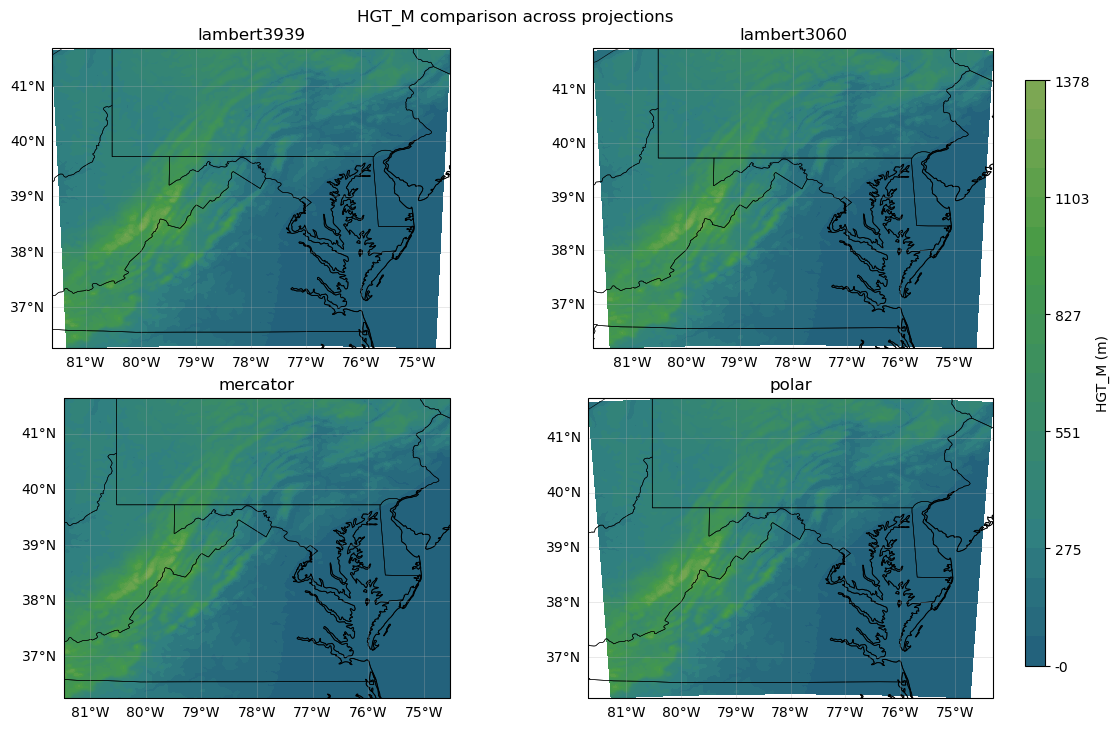

In [20]:
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter
import numpy as np

order = ["lambert3939", "lambert3060", "mercator", "polar"]

hgt_all = [datasets[name]["HGT_M"].isel(Time=0) for name in order]
vmin = float(min(h.min().item() for h in hgt_all))
vmax = float(max(h.max().item() for h in hgt_all))

norm = Normalize(vmin=vmin, vmax=vmax)
norm = WaterLandNormalize(vmin=0, vmax=3000, water_frac=0.2)

levels = np.linspace(vmin, vmax, 21)

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), subplot_kw={"projection": proj},
                         constrained_layout=True)
axes = axes.ravel()

mappable = None
for ax, name in zip(axes, order):
    ds = datasets[name]
    hgt_m = ds["HGT_M"].isel(Time=0)
    lat = ds["XLAT_M"].isel(Time=0)
    lon = ds["XLONG_M"].isel(Time=0)

    bounds = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]
    ax.set_extent(bounds, crs=proj)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    cf = ax.contourf(
        lon, lat, hgt_m,
        levels=levels,
        transform=proj,
        cmap="gist_earth",
        norm=norm,
        extend="neither"
    )

    ax.set_title(name)
    mappable = cf

# Shared colorbar (match the contour bins)
cbar = fig.colorbar(
    mappable, ax=axes, pad=0.03, shrink=0.9, aspect=30,
    boundaries=levels, spacing="proportional"
)

ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
cbar.set_label("HGT_M (m)")

fig.suptitle("HGT_M comparison across projections", y=1.02)

save = "HGT_M_compare_4projections.png"
fig.savefig(save, dpi=200, bbox_inches="tight")
print(f"[OK] Saved figure → {save}")
plt.show()


Common bounds: [-81.47217559814453, -74.52782440185547, 36.256805419921875, 41.6466178894043]
[OK] Saved figure → HGT_M_compare_4projections.png


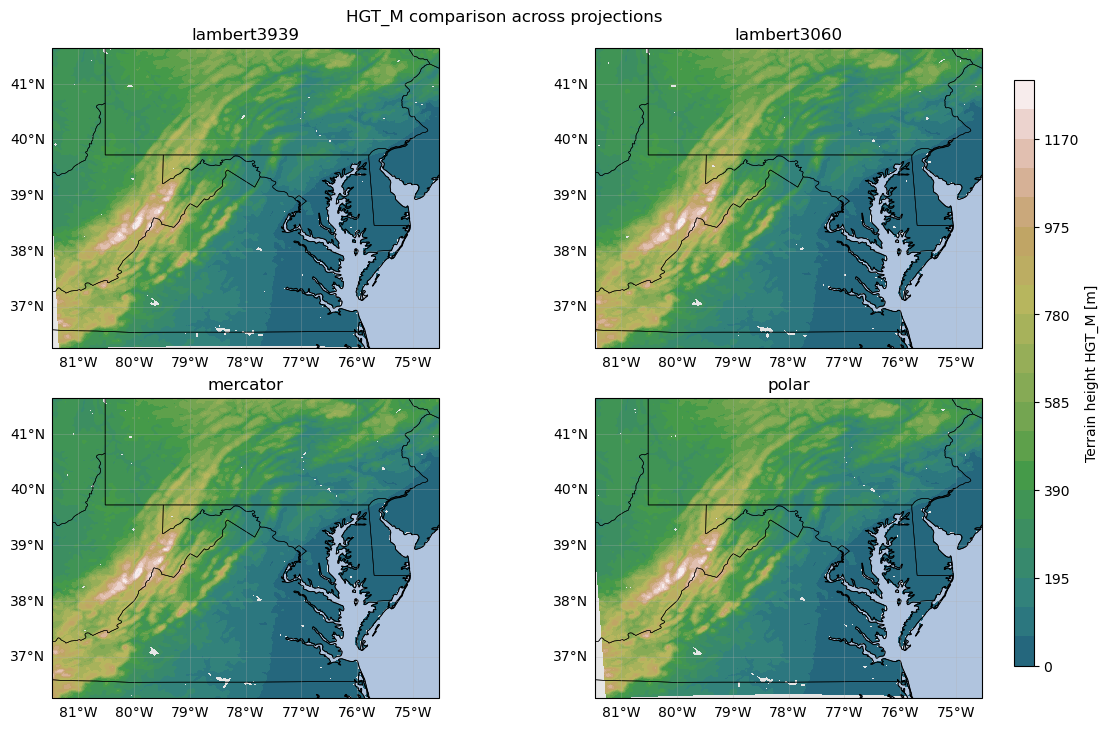

In [31]:
from matplotlib.ticker import FormatStrFormatter
import numpy as np

order = ["lambert3939", "lambert3060", "mercator", "polar"]

# Use the same fixed range as your single plot
vmin_plot, vmax_plot = 0, 1300
norm = WaterLandNormalize(vmin=vmin_plot, vmax=vmax_plot, water_frac=0.2)
# norm = Normalize(vmin=vmin_plot, vmax=vmax_plot)  
levels = np.linspace(vmin_plot, vmax_plot, 21)

lonmins = [float(datasets[n]["XLONG_M"].isel(Time=0).min()) for n in order]
lonmaxs = [float(datasets[n]["XLONG_M"].isel(Time=0).max()) for n in order]
latmins = [float(datasets[n]["XLAT_M"].isel(Time=0).min()) for n in order]
latmaxs = [float(datasets[n]["XLAT_M"].isel(Time=0).max()) for n in order]

# intersection: everyone covers this region
bounds_common = [max(lonmins), min(lonmaxs), max(latmins), min(latmaxs)]
print("Common bounds:", bounds_common)



proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2, 2, figsize=(12, 7),
    subplot_kw={"projection": proj},
    constrained_layout=True
)
axes = axes.ravel()

mappable = None
for ax, name in zip(axes, order):
    ds = datasets[name]
    hgt_m = ds["HGT_M"].isel(Time=0)
    lat = ds["XLAT_M"].isel(Time=0)
    lon = ds["XLONG_M"].isel(Time=0)
    landmask = ds["LANDMASK"].isel(Time=0)   # 1=land, 0=water
    hgt_land = hgt_m.where(landmask == 1)    # water becomes NaN (not drawn)


    bounds = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]
    ax.set_extent(bounds_common, crs=proj)
#     ax.set_extent(bounds, crs=proj)

    ax.add_feature(cfeature.LAND, facecolor="0.9")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    ax.set_facecolor("lightsteelblue")
    ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)


    cf = ax.contourf(
        lon, lat, hgt_land,
        levels=levels,          # <-- matches norm
        cmap="gist_earth",
        norm=norm,
        transform=proj,
        extend="neither"
    )

    ax.set_title(name)
    mappable = cf
    
    ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", zorder=0)

# Shared colorbar
cbar = fig.colorbar(
    mappable, ax=axes,
    pad=0.03, shrink=0.9, aspect=30,
    boundaries=levels, spacing="proportional"
)
cbar.set_label("Terrain height HGT_M [m]")
# cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

fig.suptitle("HGT_M comparison across projections", y=1.02)

save = "HGT_M_compare_4projections.png"
fig.savefig(save, dpi=200, bbox_inches="tight")
print(f"[OK] Saved figure → {save}")
plt.show()

